![Clase aprendizaje no supervisado](https://raw.githubusercontent.com/MECA4605-Aprendizaje-no-supervisado/taller_2/main/figs/taller-meca-aprendizaje%20no%20supervisado_banner%201169%20x%20200%20px%20-05.png)

# Caso-taller:  Segmentación de Clientes con Clustering Jerárquico y DBSCAN

El objetivo de este caso-taller es analizar una base de datos ficticia sobre clientes de una tienda y buscar encontrar grupos de clientes que permitan generar estrategias de marketing focalizadas. La base se encuentra en los `Archivos de Laboratorio` en la carpeta `data` y cuenta con 200 observaciones y 5 variables:

- `Id_Cliente`: identificador de cliente.
- `Genero`: género del cliente: Mujer, Hombre
- `Edad`: edad en años
- `Ingreso`: ingresos anuales
- `Puntaje_Gasto`: es una variable que mide cuán a menudo un cliente compra en la tienda, siendo 100 el puntaje más alto.


## Instrucciones generales

1. Para desarrollar el *cuaderno* primero debe descargarlo.

2. Para responder cada inciso deberá utilizar el espacio debidamente especificado.

3. La actividad será calificada sólo si sube el *cuaderno* de jupyter notebook con extensión `.ipynb` en la actividad designada como "entrega calificada por el personal".

4. El archivo entregado debe poder ser ejecutado localmente por el tutor. Sea cuidadoso con la especificación de la ubicación de los archivos de soporte, guarde la carpeta de datos en el mismo `path` de su cuaderno, por ejemplo: `data`.

## Alistar ambiente de trabajo

> Nota función here(): Para usar la función here() es necesario crear un archivo vació llamado .here que le indique a la función cuál es el directorio de trabajo. Recomiendo crear el archivo desde la terminal para no tender problemas con las extensiones

In [1]:
#Cargar paquetes necesarios ----------------------------------------------
from pyprojroot import here # Referenciación de archivos, es here() para python 
from pathlib import Path # Facilita rutas a los archivos 
import pandas as pd #Análisis de datos
import numpy as np #Cálculos numéricos
import os #Definir el directorio
import seaborn as sns #Visualización de datos
from matplotlib import pyplot as plt #Visualización de datos
from sklearn.cluster import AgglomerativeClustering #Implementar clúster jerárquico

In [2]:
#Definir el directorio de trabajo ----------------------------------------
wd = here()
os.chdir(wd)
os.listdir()

['.DS_Store',
 '.here',
 'figs',
 'S4_Taller_Jerarquico_DBSCAN.ipynb',
 'S3_Taller_Kmeans_Kmedoids.ipynb',
 'data']

## Desarrollo


### 1.Carga de datos

En la carpeta `data` se encuentra el archivo `datos_clientes.csv` cargue estos datos en su *cuaderno*.

In [3]:
#Cargar datos ---------------------------------------------------
clientes_db = pd.read_csv("data/datos_clientes.csv")
clientes_db =clientes_db.set_index("Id_Cliente") #Dejamos el id como índice de la base
clientes_db.head()

,Genero,Edad,Ingreso,Puntaje_Gasto
Id_Cliente,,,,
1,Mujer,41,98115.05,39
2,Mujer,20,35458.14,75
3,Mujer,68,59872.08,55
4,Hombre,63,48508.93,51
5,Mujer,31,44431.11,54


### 2. Análisis preliminar.

Antes de comenzar el análisis de segmentación utilice estadísticas descriptivas para explorar la variables que se encuentran en los datos. En su análisis mencione si hay patrones que surgen del examen descriptivo de los datos; entre ellos si hay diferencias en los ingresos y los puntajes de gastos para mujeres y hombres, por grupos etarios (18-24, 25-34, 35-44, 45-54, 55-64, y 65+), y por grupos etarios y género. Discuta además si estas diferencias son estadísticamente significativas.

#### 2.1 Explorar la estructura y las variables de la base
Buscamos encontrar: 

* ¿Cuantas observaciones tiene la base?
* ¿Qué varaibles tiene la base?
* ¿Tenemos observaciones duplicadas o valores faltantes?

In [4]:
#Cuantas observaciones tiene la base --------------------------------
print(f"La base clientes tiene: {clientes_db.shape[0]}")

La base clientes tiene: 200


In [5]:
#Cuantas variables tiene la base y de que tipo -------------------

print(f"Resumen de base (Total: {clientes_db.shape[0]} registros):")
print("-" * 40)

for variable in clientes_db.columns:
    
    print(f"Columna: {variable:<25} | Tipo: {clientes_db[variable].dtype}")


Resumen de base (Total: 200 registros):
----------------------------------------
Columna: Genero                    | Tipo: object
Columna: Edad                      | Tipo: int64
Columna: Ingreso                   | Tipo: float64
Columna: Puntaje_Gasto             | Tipo: int64


In [6]:
#Estadísticas descriptivas de las variable ---------------------------
print(clientes_db.describe(include="all"))

       Genero        Edad        Ingreso  Puntaje_Gasto
count     200  200.000000     200.000000     200.000000
unique      2         NaN            NaN            NaN
top     Mujer         NaN            NaN            NaN
freq      112         NaN            NaN            NaN
mean      NaN   38.850000   60624.446600      50.200000
std       NaN   13.969007   26262.903416      25.823522
min       NaN   18.000000   13458.020000       1.000000
25%       NaN   28.750000   41512.787500      34.750000
50%       NaN   36.000000   60777.960000      50.000000
75%       NaN   49.000000   77143.865000      73.000000
max       NaN   70.000000  138584.520000      99.000000


In [7]:
#Revisemos si la base tiene datos faltantes o duplicados ----------------------
print(f"{'Variable':<20} |{'NAs':<6}")
print("-" * 30)

for variable in clientes_db.columns:
    #Contar missings por variable
    na_count = clientes_db[variable].isna().sum()
    
    #Ver missings por variable
    print(f"{variable:<20} | {na_count:<6}")


#Contar duplicados en la base 
print("-" * 30)
print(f"La base tiene {clientes_db.duplicated().sum()} duplicados")


Variable             |NAs   
------------------------------
Genero               | 0     
Edad                 | 0     
Ingreso              | 0     
Puntaje_Gasto        | 0     
------------------------------
La base tiene 0 duplicados


La base tiene 200 observaciones perfectamente identificadas que corresponden a personas. Para cada persona tenemos: 

**Variables númericas**
* Edad
* Ingreso
* Puntaje de gastos 

**Variables categóricas**
* Genero

Ninguna variable tiene valores faltantes 

#### 2.2 Poner las variables en su tipo correcto 
Vamos a poner la variable género como categórica

In [8]:
clientes_db["Genero"] = clientes_db["Genero"].astype("category")

#### 2.3 Análisis Univariado

##### 2.3.1 Variables númericas 

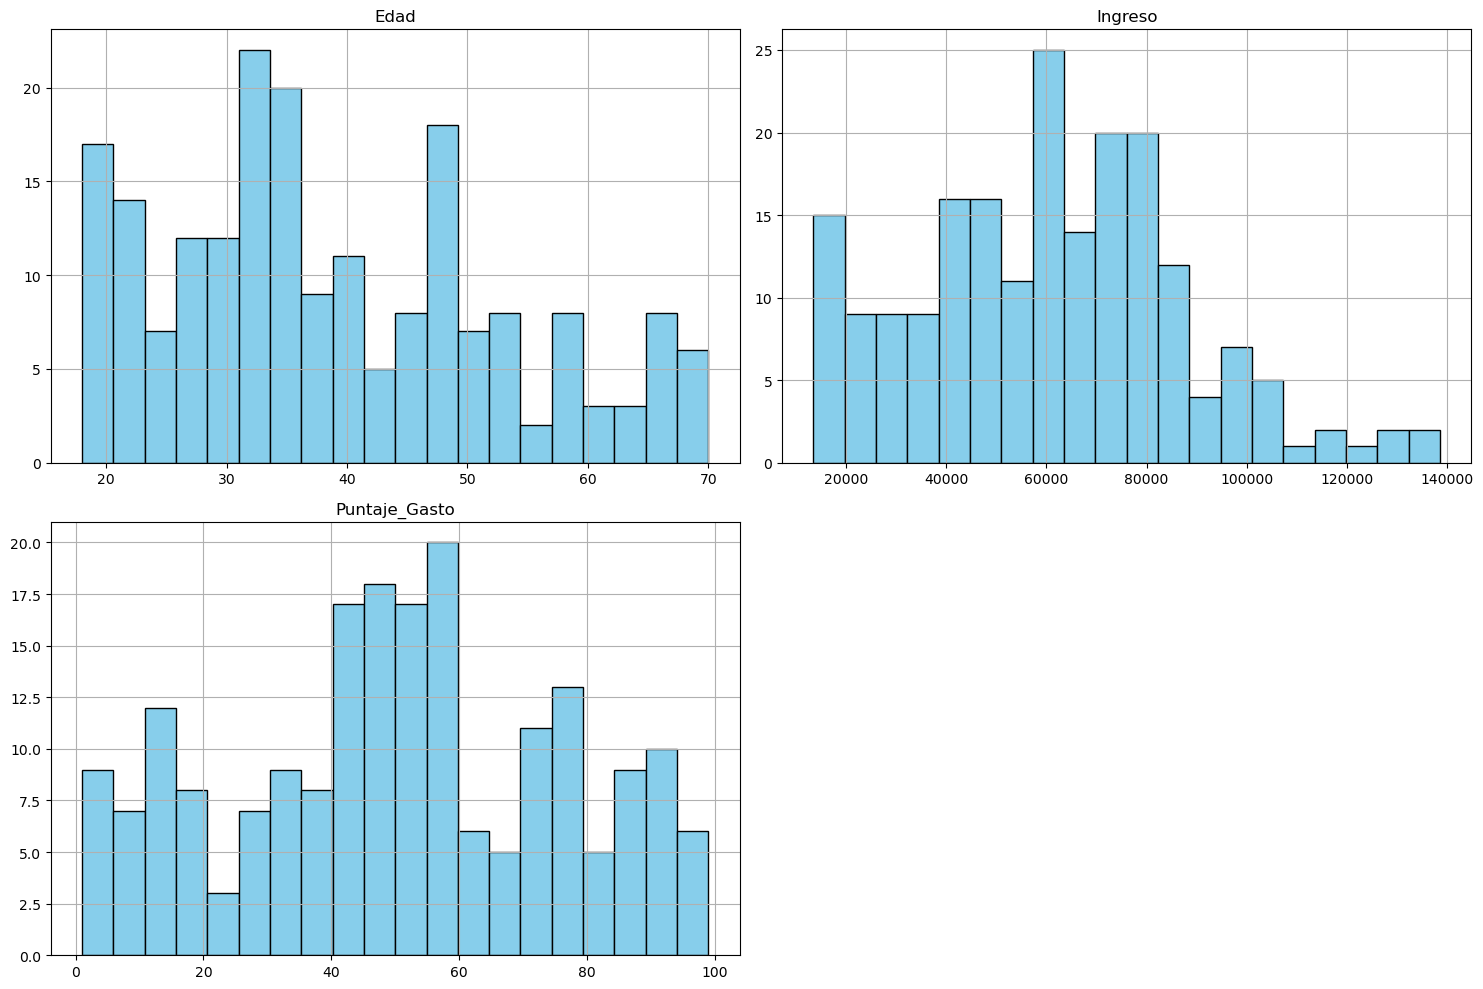

In [9]:
#Histogramas de las variables de medición  ----------------------------------------
clientes_db.hist(bins=20, figsize=(15, 10), color='skyblue', edgecolor='black')
plt.tight_layout()
plt.show()

La variables *Edad* e *Ingresos* tienen distribuciones con colas izquierdas más pesadas. La variable puntaje de gastos tiene una distribución más parecidas a normal. 

#### 2.3.2 Variables categóricas 

/var/folders/nb/vtcsx_lj1yq4skfdq47wggjw0000gn/T/ipykernel_61191/3693549617.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=clientes_db, y='Genero', palette='magma')


<Axes: xlabel='count', ylabel='Genero'>

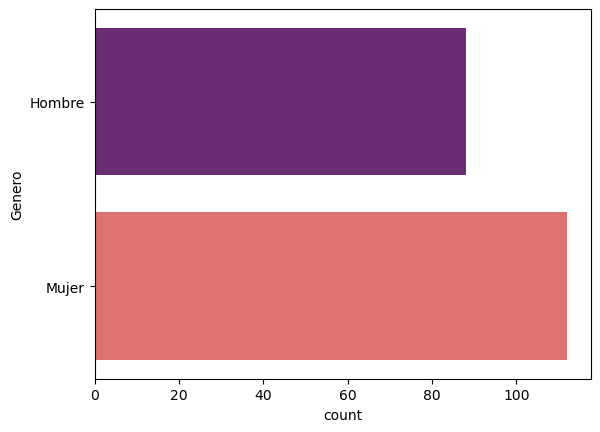

In [10]:
sns.countplot(data=clientes_db, y='Genero', palette='magma')

Hay más mujeres que hombres en la base, pero no muestra un desbalance de clases

### 2.4 Análisis Univariado

Antes de empezar el análisis vamos a crear una variable que clasifique a la población en grupos según su edad

/var/folders/nb/vtcsx_lj1yq4skfdq47wggjw0000gn/T/ipykernel_61191/3977055474.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=clientes_db, y='Rango_Etario', palette='magma')


<Axes: xlabel='count', ylabel='Rango_Etario'>

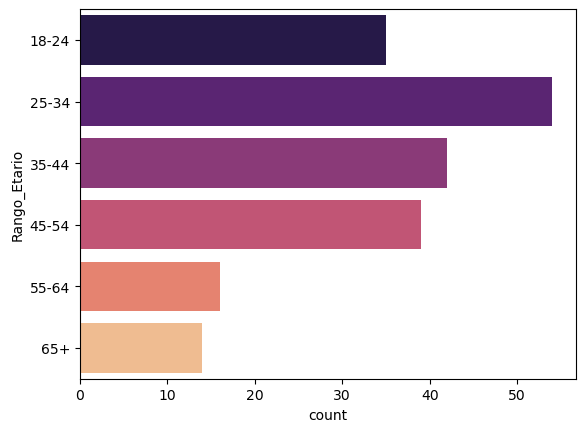

In [11]:
#Establece los intervalos del rango etario
bins = [18, 25, 35, 45, 55, 65, float('inf')]

#Definimos los nombres de los intervalos
labels = ['18-24', '25-34', '35-44', '45-54', '55-64', '65+']

#Creamos la variable Rango Etario
clientes_db['Rango_Etario'] = pd.cut(clientes_db['Edad'], bins=bins, labels=labels, right=False)

#Ver distribuciones por grupos de edad 
sns.countplot(data=clientes_db, y='Rango_Etario', palette='magma')

vemos que la mayoría de las personas en la base se concentran entre 18.54 años. Ahora veamos las diferencias por genero y grupo etario para las diferentes variables

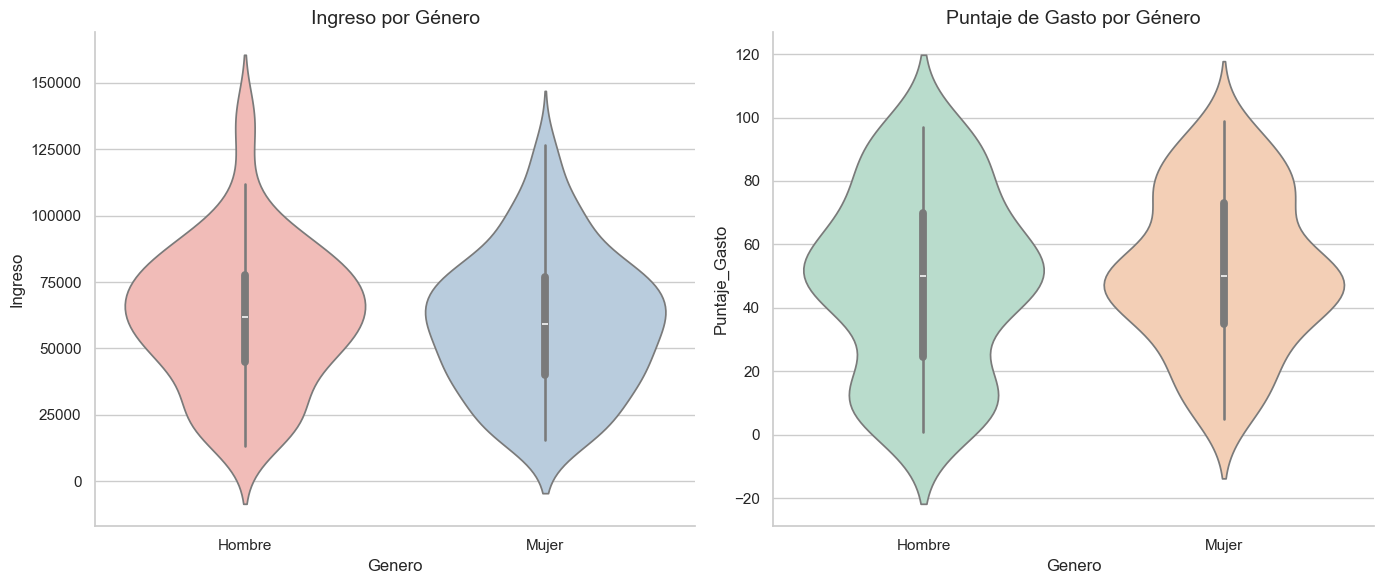

In [12]:
#Tema de la gráfica
sns.set_theme(style="whitegrid")

#Indicar que vamos a hacer dos columnas, una para género
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

#Gráfico ingreso por gémero
sns.violinplot(data=clientes_db, x='Genero', y='Ingreso', 
               hue='Genero', palette='Pastel1', inner='box', ax=axes[0], legend=False)
axes[0].set_title('Ingreso por Género', fontsize=14)

#Gráfico puntaje de gasto por género
sns.violinplot(data=clientes_db, x='Genero', y='Puntaje_Gasto', 
               hue='Genero', palette='Pastel2', inner='box', ax=axes[1], legend=False)
axes[1].set_title('Puntaje de Gasto por Género', fontsize=14)

sns.despine()
plt.tight_layout()
plt.show()

**Ingreso por género:** Ambos géneros que están en relativamente el mimso rango de ingresos. Sin embargo, los hombres están más dispersos a lo largo de este rango. Esto implica que es los hombres tienen ingresos más difrentes entre sí que las mujeres. 

**Puntaje de gastos:** En este caso, las distrubición de ambos esta más concentrada en los puntajes de gastos más altos. Sin embargo, la de los hombre está más aún concentrada que la de mujeres en los puntajes más altos. Para ambos géneros, las personas se concentran por encima de la media, pero para los hombres esto es aún mayor. 

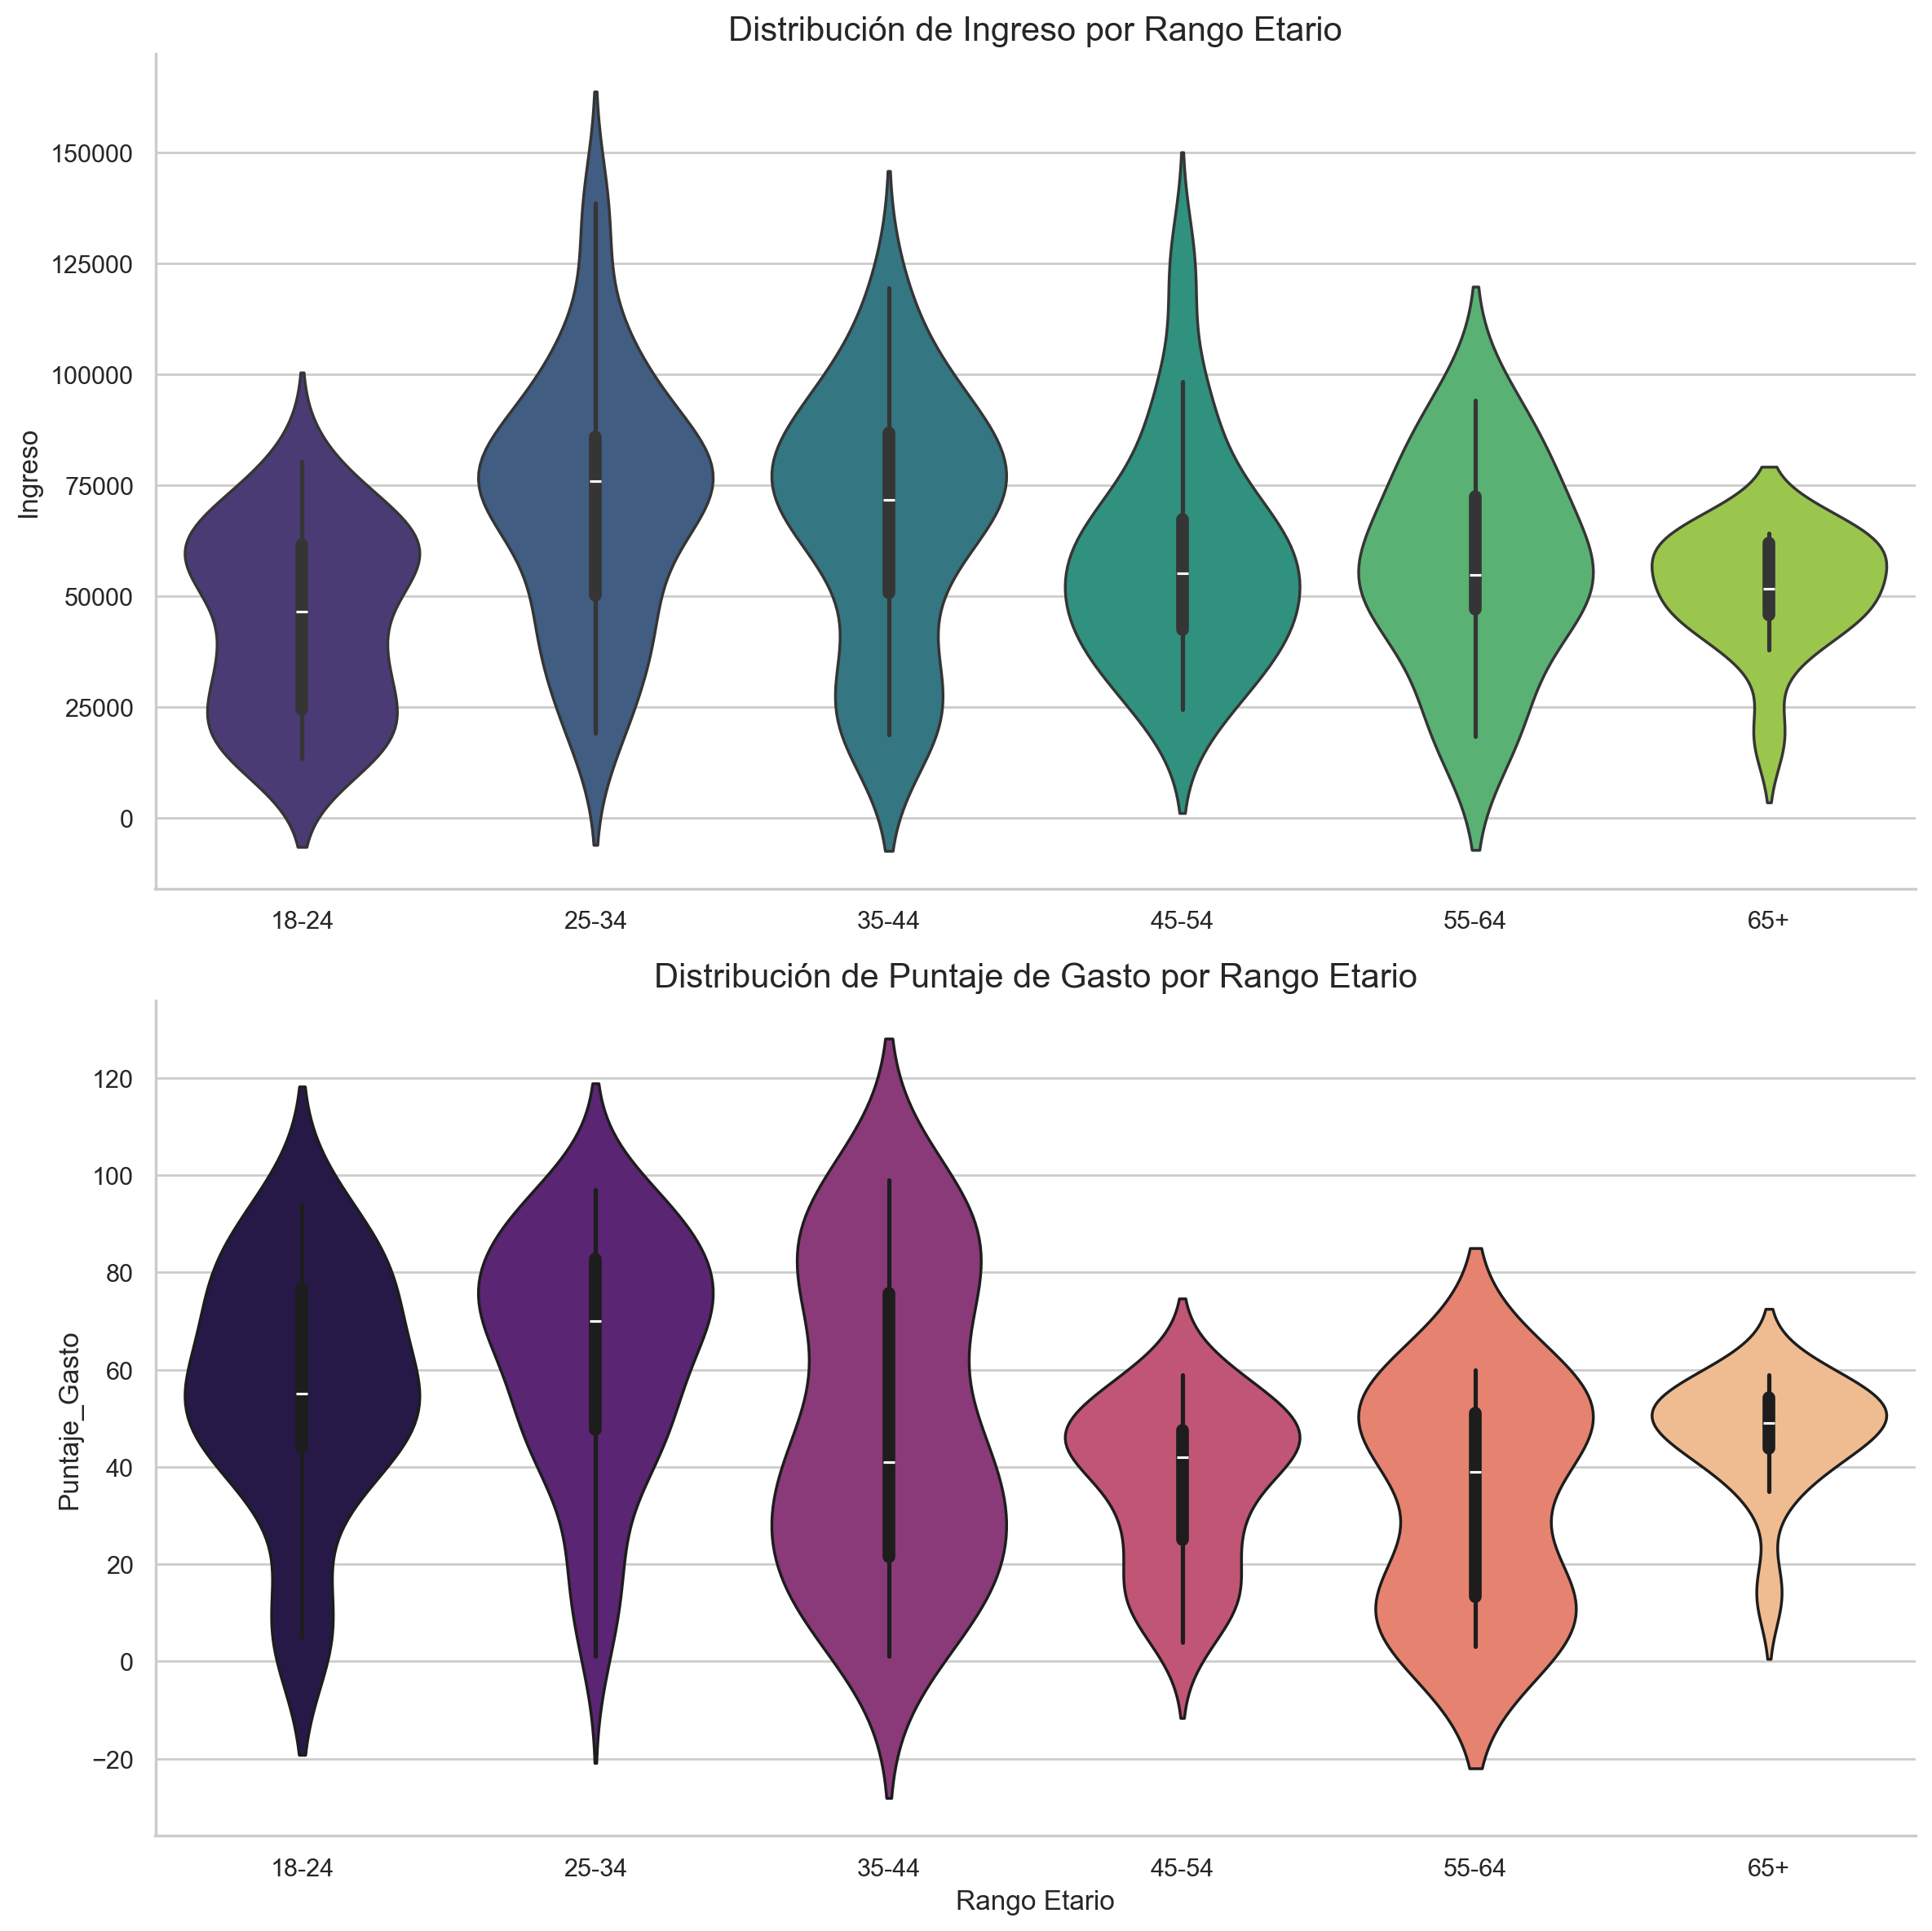

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# High-resolution for Mac Retina displays
%config InlineBackend.figure_format = 'retina'
sns.set_theme(style="whitegrid")

# 1. Create a figure with 2 rows (one for each metric)
# Using 2 rows instead of 2 columns makes the age groups easier to read on the X-axis
fig, axes = plt.subplots(2, 1, figsize=(12, 12))

# Subplot 1: Ingreso vs Rango_Etario
sns.violinplot(
    data=clientes_db, 
    x='Rango_Etario', 
    y='Ingreso', 
    hue='Rango_Etario', 
    palette='viridis', 
    inner='box', 
    ax=axes[0],
    legend=False
)
axes[0].set_title('Distribución de Ingreso por Rango Etario', fontsize=15)
axes[0].set_xlabel('') # Hide x-label on top plot to save space

# Subplot 2: Puntaje_Gasto vs Rango_Etario
sns.violinplot(
    data=clientes_db, 
    x='Rango_Etario', 
    y='Puntaje_Gasto', 
    hue='Rango_Etario', 
    palette='magma', 
    inner='box', 
    ax=axes[1],
    legend=False
)
axes[1].set_title('Distribución de Puntaje de Gasto por Rango Etario', fontsize=15)
axes[1].set_xlabel('Rango Etario', fontsize=12)

# Clean up layout
sns.despine()
plt.tight_layout()
plt.show()

**Ingreso de las personas según su rango etario**
1. Las personas más jóvenes son las que tienen menos ingresos. Esto es plausible porque están terminando sus estudios y no se han incoporado en el fuerza laboral o están empezando sus carreras profesionales. 
2. De entre los 25-44 las personas en promedio tienen ingresos mayores relativo a los demás grupos. En este rango las personas yo tienen más experiencia laboral y han culminado sus estudios. Esto probablemente explica el aumento en los ingresos. 
3. El grupo entre 45-54 años presenta un comportamiento inesperado. Las personas aún no se han retirado y por su nivel de experiencia es probable que tengan cargos directivos. Sin embargo, este grupo tiene un nivel de ingreso menor relativo a los dos anteriores. Es importante revisar si otra variable explica este comportamiento
4. Los últimos dos grupos (55 - 65+): Presentan una ingresos menores con respecto a los demás grupos, salvo los jóvenes. Es probable que estás personas esten próximas a retirarse o retiradas. Por lo cual, la disminución de sus ingresos se explicaría porque ahora devengan una pensión o renta menor a su anterior salario. 

**Ingreso de las personas según su rango etario**
1. Las personas más jóvenes tienen un nivel de gastos elevado con respecto a los demás grupos. Esto podría explicarse porque en este etapa de la vida sus padres costean sus gastos y están haciendo inversiones en educación, que son costosas. 
2. De entre los 25-44 las personas en promedio gastan que los demás grupos. Esto podría explicarse porque las personas están adquiriendo su vivienda, carro, muebles, entre otros bienes y están financiando los primeros años de sus hijos. 
3. De los 45 en adelante las personas gastan menos. Esto podría explicarse porque ya tienen un patrimonio consolidado y ya están terminando o terminaron de pagar a sus hijo porque ya crecieron. También podrían estar restructurando sus gastos anticipando a la caída en sus ingreso que vendrá cuando se retiren. 

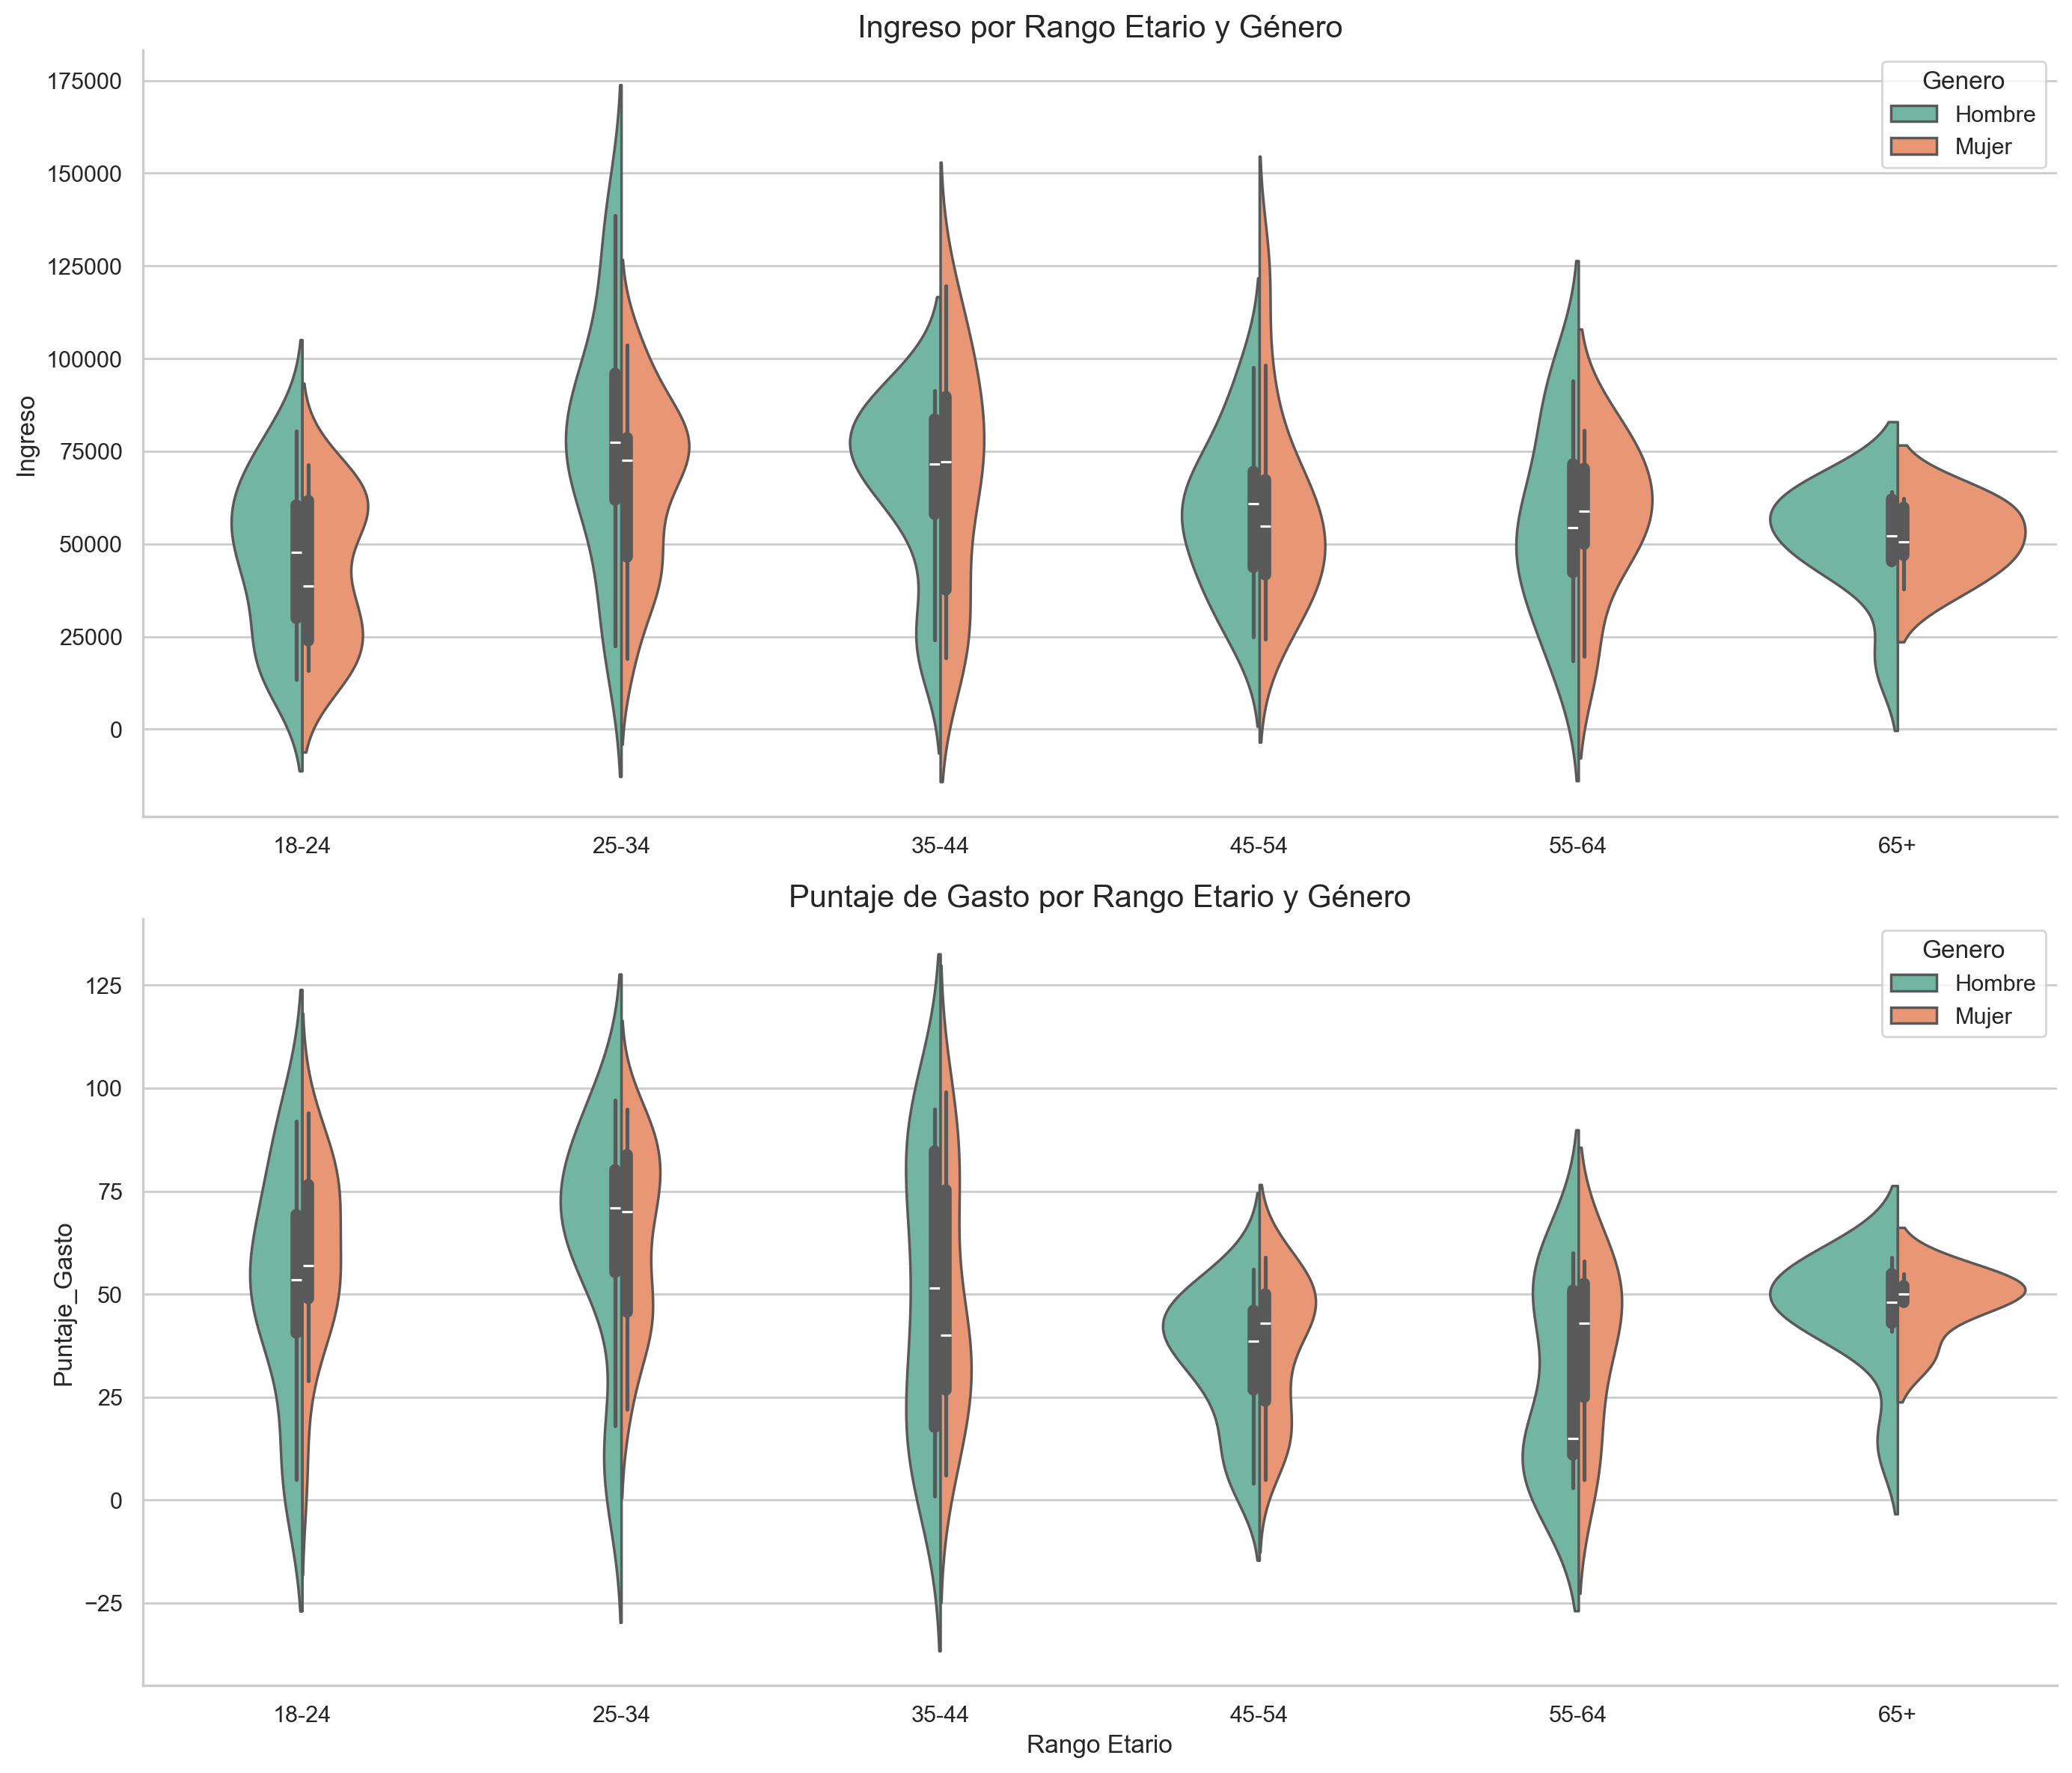

In [14]:


#Tema de la gráfica
sns.set_theme(style="whitegrid")

#Organizamos el canvas de la figura
fig, axes = plt.subplots(2, 1, figsize=(14, 12))

#Gráficos por ingreso
sns.violinplot(
    data=clientes_db, 
    x='Rango_Etario', 
    y='Ingreso', 
    hue='Genero', 
    palette='Set2', 
    inner='box',   # Mantiene el boxplot adentro del violín
    split=True,    # Pega las dos mitades del violín (Hombre/Mujer) en una sola forma
    ax=axes[0]
)
axes[0].set_title('Ingreso por Rango Etario y Género', fontsize=15)
axes[0].set_xlabel('') 

#Gráfico por puntaje de gastos
sns.violinplot(
    data=clientes_db, 
    x='Rango_Etario', 
    y='Puntaje_Gasto', 
    hue='Genero', 
    palette='Set2', 
    inner='box',   # Mantiene el boxplot adentro
    split=True,    # Pega las dos mitades
    ax=axes[1]
)
axes[1].set_title('Puntaje de Gasto por Rango Etario y Género', fontsize=15)
axes[1].set_xlabel('Rango Etario', fontsize=12)

sns.despine()
plt.tight_layout()
plt.show()

Ambos géneros muestran en promedio comportamientos similares a lo largo de los rangos etarios en sus ingresos y gastos. Para ambos géneros los rangos etarios con mayor dispersión son los primeros tres. Sin embargo, estos rangos etarios también concentran más de la mitad de las personas de base, lo que podría explicar la dispersión. 

> Preliminarmente parece que para estás personas la edad están más relacionada con los ingresos y los gastos que el género. 

### 3. Clustering Jerárquico

#### 3.1. Dendrogramas

Agrupe a los clientes utilizando sólo dos variables: su ingreso y el puntaje de gastos. Para ello retenga estas dos variables, estandarízelas, construya y grafique un dendograma. Para la construcción del dendrograma utilice el enlace 'ward' y la distancia euclidiana. Explique la importnacia de estandarizar los datos.

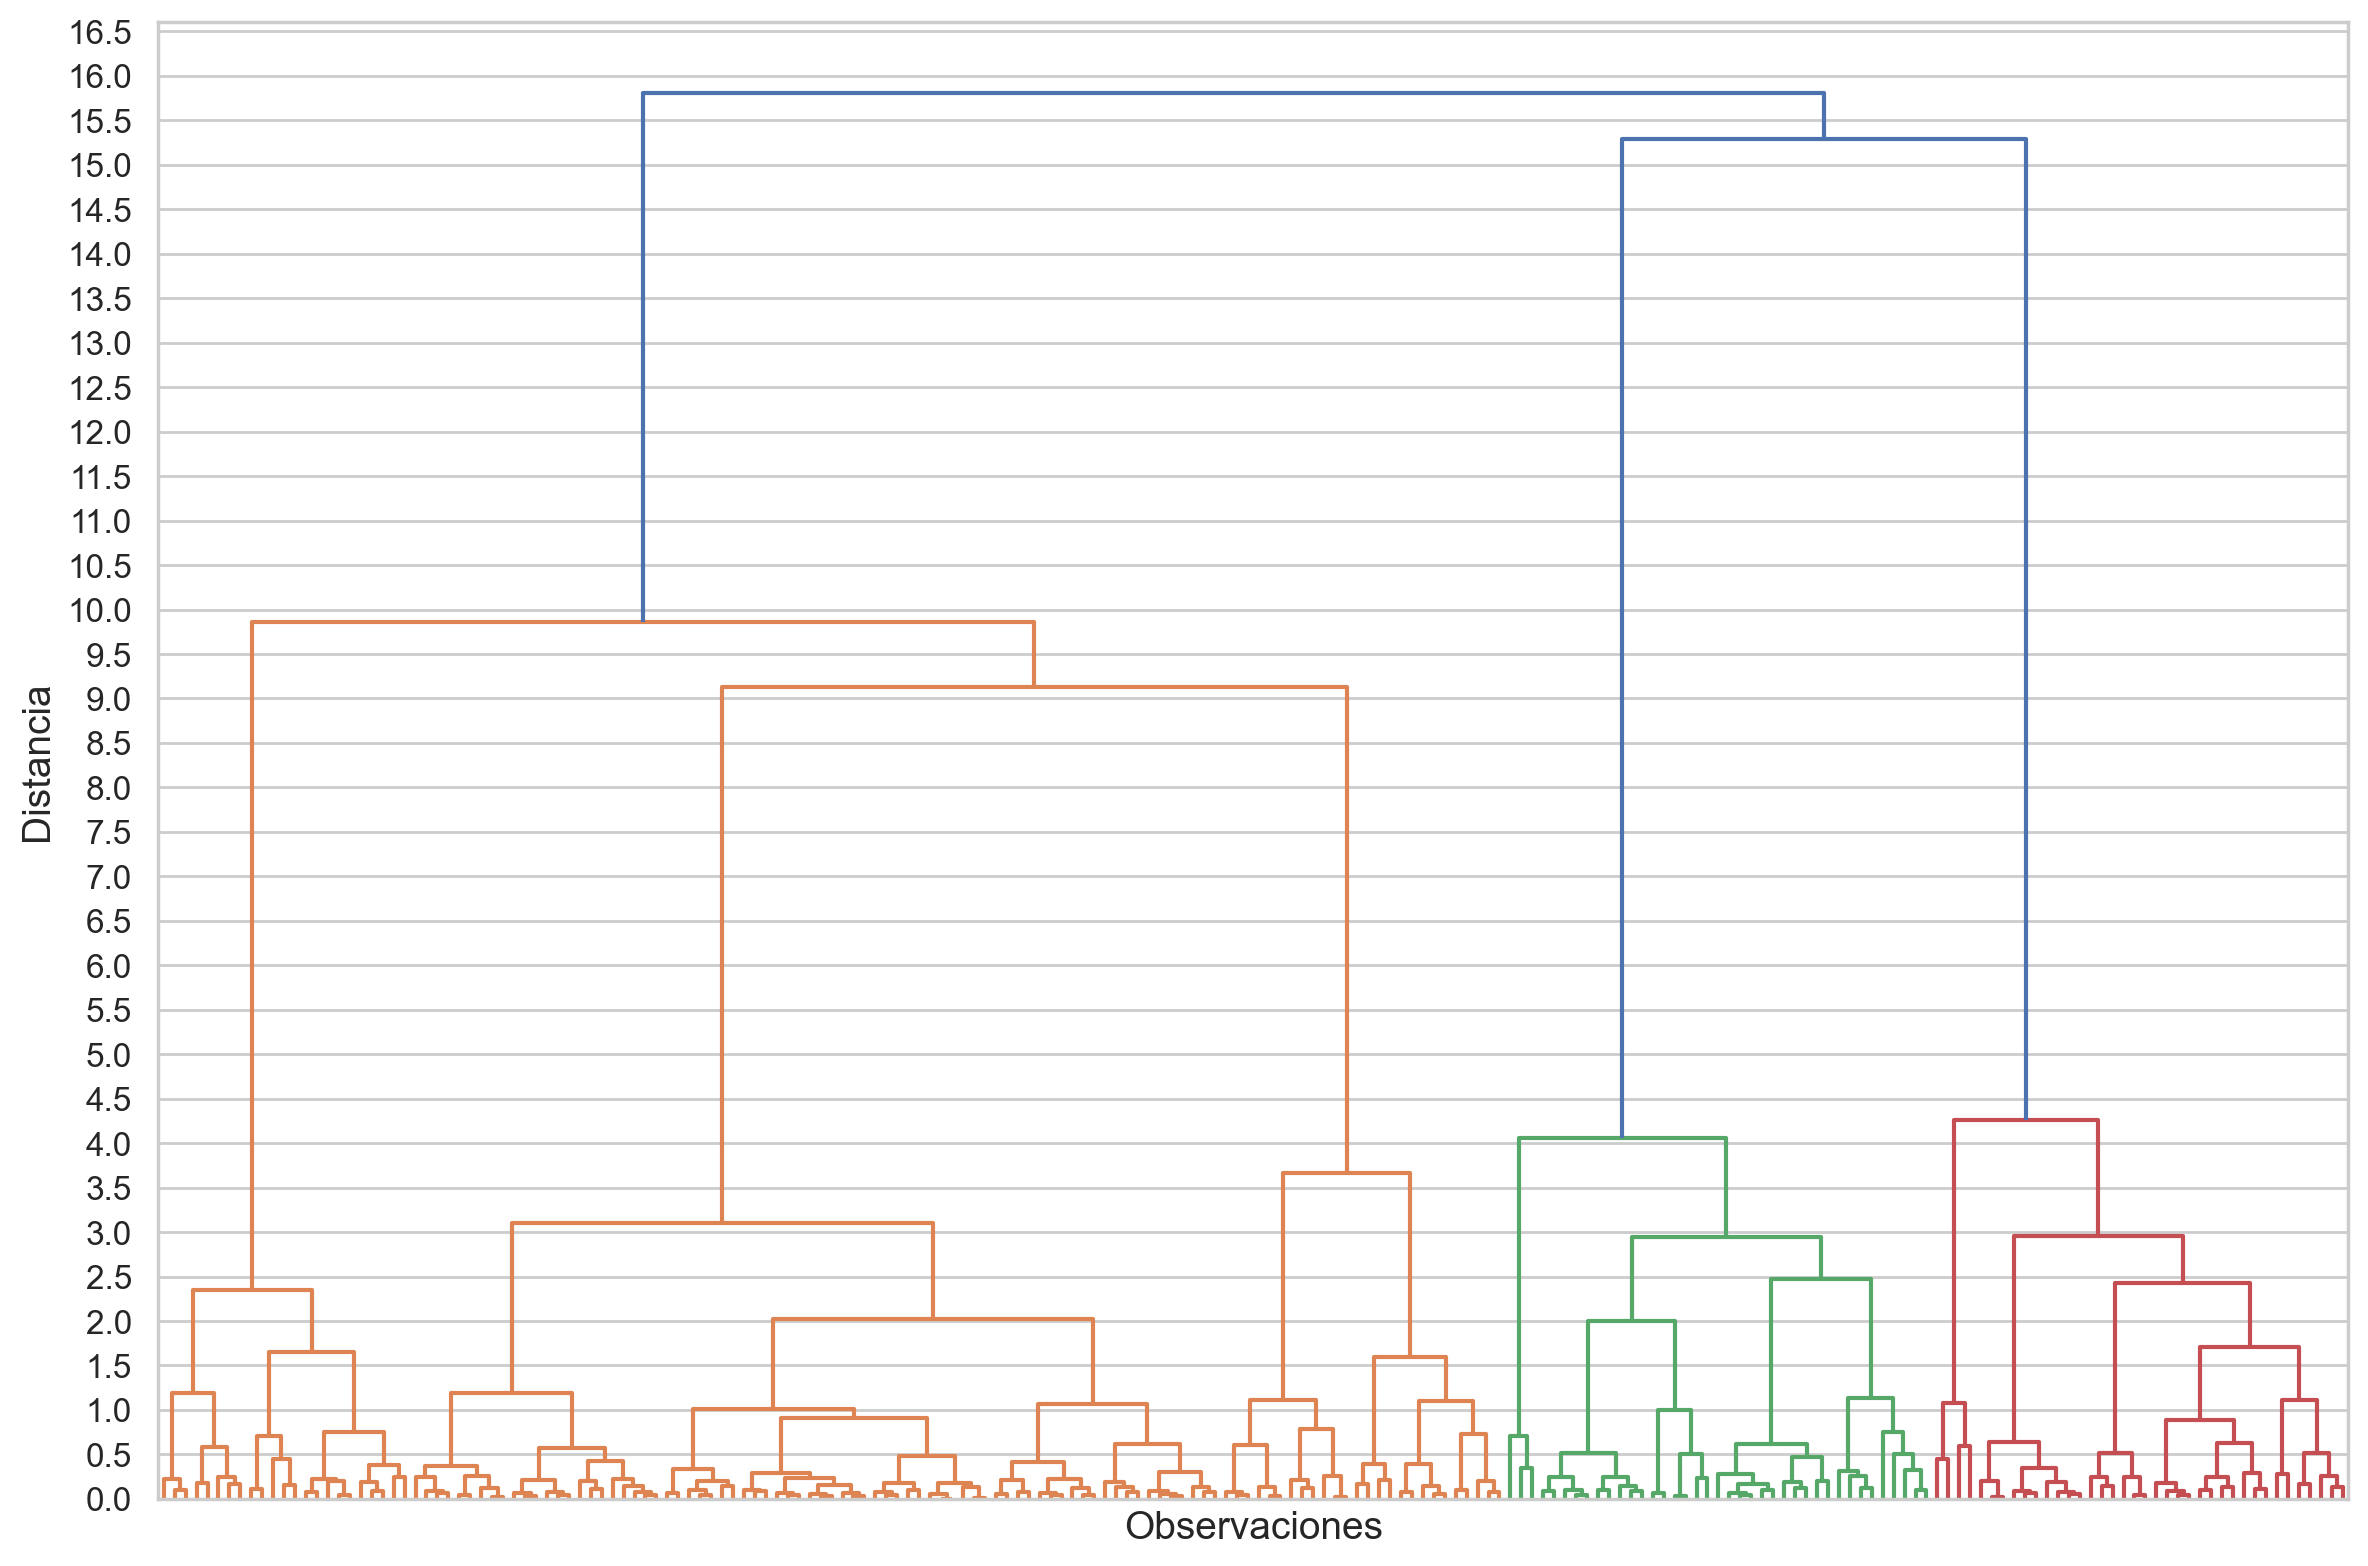

In [15]:
#Hacer una base solo con las variables Ingreso y Puntaje de Gastos -------------------------
money_situation_db = clientes_db[["Ingreso", "Puntaje_Gasto"]].copy()

#Estandarizar variables--------------------------
from sklearn.preprocessing import StandardScaler

#Definir función para estandarizar
scaler = StandardScaler()

#Estandarizar las variables
money_situation_scaled = scaler.fit_transform(money_situation_db)

#Pasar la db de tipo numpy a pandas
money_situation_db_scaled = pd.DataFrame(
    money_situation_scaled, 
    columns=money_situation_db.columns
)

#Calcular distancias y definir el enlace  ---------------------
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage

dist = pdist(money_situation_db_scaled, metric='euclidean')
Z = linkage(dist, method='ward')

#Construcción del dendrograma ---------------------
from scipy.cluster.hierarchy import dendrogram

fig, ax = plt.subplots(figsize=(12, 8))
d = dendrogram(
    Z,
    no_labels=True,
    show_leaf_counts=True,
    leaf_font_size=14,
    ax=ax
)

ax.set_xlabel('Observaciones', fontsize=14)
ax.set_ylabel('Distancia', fontsize=14)

y_max = ax.get_ylim()[1]
ax.set_yticks(np.arange(0, y_max, 0.5))
ax.tick_params(axis='y', labelsize=12)

plt.tight_layout()
plt.show()



Es indispensable estandarizar las variables porque las medidas de distancia/disimilitud son sensibles a la escala de la unidad de medida. Si no estandarizamos las variables en vez de ver las diferencias entre las observaciones podríamos ver una distosión inducida por la unidad de media. 

> Ejemplo: 20 años de experencia hacen que dos personas sean más difentes que una diferencia de 500 mil pesos en su salario. Pero, por la escala podríamos ver que el modelo considera que el salario diferencia más a las personas que los años de experiencia. 

#### 3.2. Número de clusters

Retenga el número de clusters que se obtengan luego de fijar la distancia en 6.

In [16]:
from scipy.cluster.hierarchy import linkage, fcluster

#Definimos el criterio para calcular la distancia 
distances = linkage(money_situation_db_scaled, method="ward", metric="euclidean")

#Calculamos los clustérs 
clusters = fcluster(distances, 6, criterion="distance")

#Ver cuántos clústeres resultaron
n_clusters = len(np.unique(clusters))
print(f"Número de clústeres a distancia 6: {n_clusters}")


Número de clústeres a distancia 6: 5


El número de clústers es muy similar al número de grupos etarios. Es probable que el algorimto haya identificado la mayoría de los grupos y agrupado dos grupos etarios que tienen observaciones similares. 

#### 3.3. Algoritmo Jerárquico Aglomerativo

Utilizando el número de clusters encontrados en el paso anterior, aplique el algoritmo jerárquico aglomerativo, utilizando el enlace 'ward' y la distancia euclidiana. Describa los grupos encontrados, en que grupo o grupos concentraría su estrategia de marketing y por qué?

##### 3.3.1 Aplicar el algoritmo

In [17]:
#Definimos el criterio para calcular la distancia 

distances = linkage(money_situation_db_scaled, method="ward", metric="euclidean")

#Calculamos los clustérs. Especificamos el número de clústers que queremos
clusters = fcluster(distances, t=5, criterion='maxclust')

print(f"Clústeres asignados: {np.unique(clusters)}")

Clústeres asignados: [1 2 3 4 5]


##### 3.3.2 Describir los grupos encontrados 

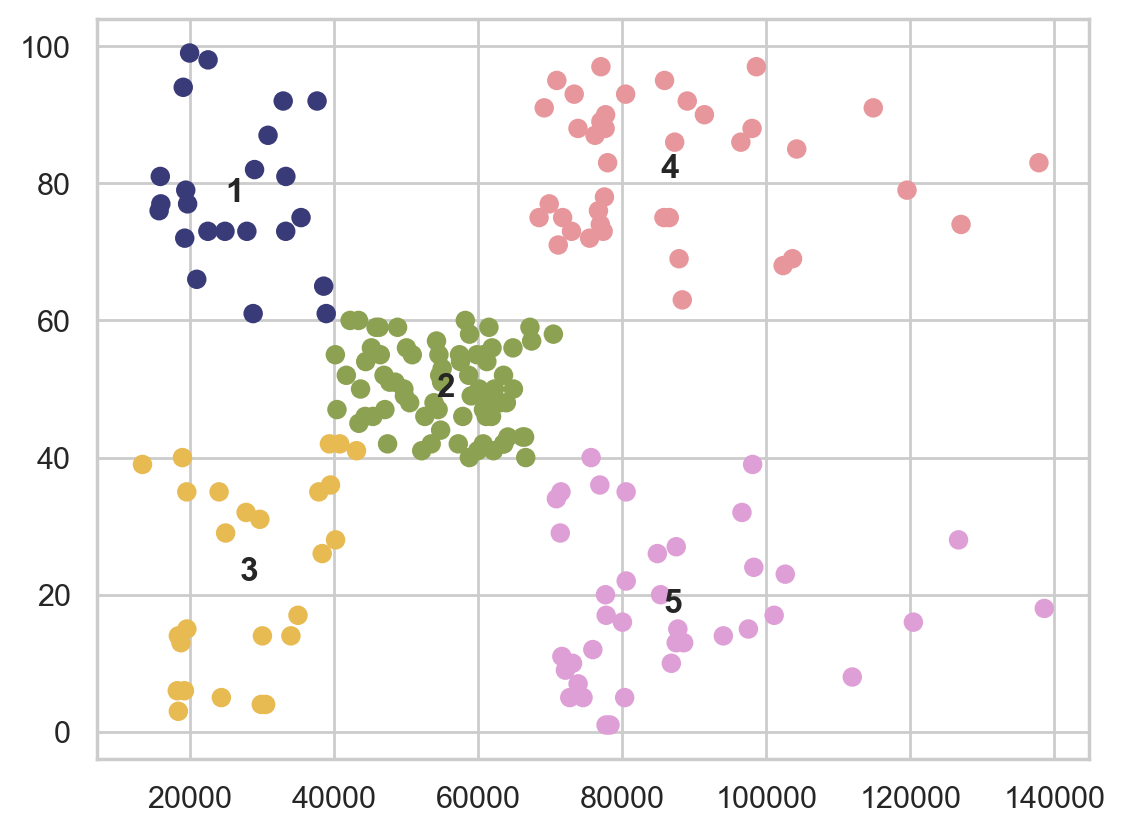

In [18]:
plt.scatter(money_situation_db['Ingreso'], money_situation_db['Puntaje_Gasto'], c=clusters, cmap='tab20b')

for cluster_id in np.unique(clusters):
    subset = money_situation_db[clusters == cluster_id]
    cx = subset['Ingreso'].mean()
    cy = subset['Puntaje_Gasto'].mean()
    plt.text(cx, cy, str(cluster_id), fontsize=12, fontweight='bold', ha='center', va='center')

plt.show()

In [19]:
#Agregar el clúster en el que quedo asignada cada persona 
money_situation_db.loc[:, "cluster"] = clusters

#Vemos cuantas personas hay por clúster
print("Número de personas por clúster")
print(money_situation_db["cluster"].value_counts())

Número de personas por clúster
cluster
2    74
4    39
5    38
3    26
1    23
Name: count, dtype: int64


In [20]:
print(money_situation_db.groupby("cluster").describe())

        Ingreso                                                               \
          count          mean           std       min         25%        50%   
cluster                                                                        
1          23.0  26230.419565   7742.413865  15766.84  19590.8100  24905.790   
2          74.0  55451.258514   7847.567060  40218.68  48594.1075  57359.505   
3          26.0  28274.667308   8998.503308  13458.02  19362.5200  28787.940   
4          39.0  86537.496410  16684.184918  68486.79  75875.5150  77996.300   
5          38.0  87055.074474  16200.102296  70888.72  75765.5100  80570.395   

                               Puntaje_Gasto                              \
                75%        max         count       mean        std   min   
cluster                                                                    
1        33157.7100   38950.66          23.0  78.565217  10.953729  61.0   
2        61796.6375   70469.66          74.0  50.216216

**Estrategia de marketing**

* *Caso 1* Se quiere alcanzar a la mayor cantidad de personas, la estrategía debería enfocarse en el grupo 2. Este es el grupo más grande y homogéneo. 
* *Caso 2* Se quiere vender un producto de lujo, la estrategía debería enfocarse en el grupo 5. Este grupo tiene el mayor nivel de ingreso y el menor puntaje de gastos, por lo tanto tienen un mayor ingreso disponible. 
* *Caso 3* Se quiere vender un producto ha poblaciones con menores ingresos (productos de inclusión financiera como nequi por ejemplo), la estrategía debería enfocarse en el grupo 1. Este grupo tiene el menor de ingresos y el segundo puntaje de gasto más alto

### 4. DBSCAN

Implemente DBSCAN, al igual que el punto anterior sólo dos variables: su ingreso y el puntaje de gastos. Al implementar  justifique su elección de `min_samples` y `eps`. ¿Cuántos grupos o clusters encuentra? ¿Cuáles son su características? ¿Cambiaría su estrategia de marketing respecto al punto anterior? Justifique su respuesta.

#### 4.1 Implementar DBSCAN

In [21]:
#Cargar funciones necesarias para implementar DBSCAN --------------------------
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

#### 4.1.2 Elegir los hiperpárametros

Vamos a usar 4 vecinos a partir de los segurido por Ester et al. (1996) teniendo en cuenta que estamos usando dos dimensiones para hacer la agrupación. 

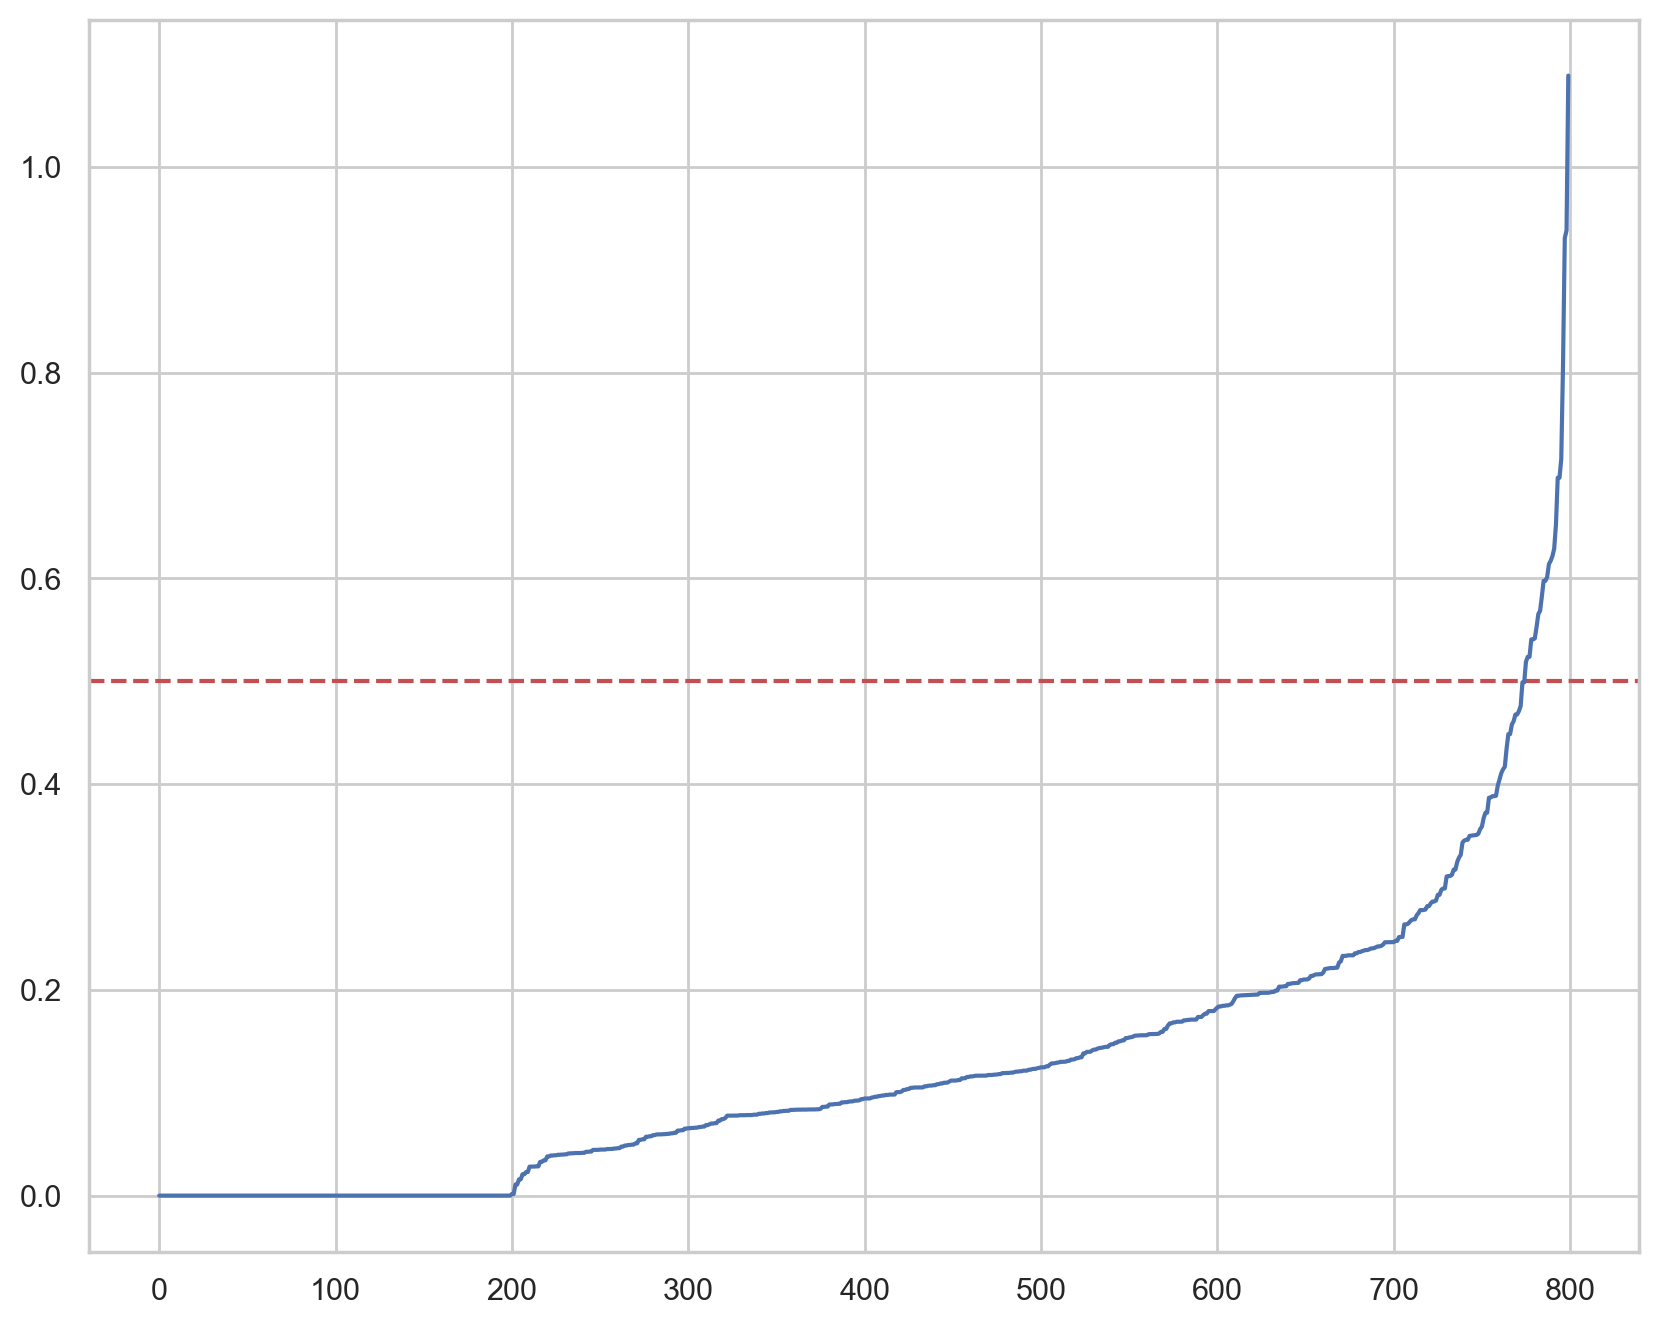

In [22]:
#Definir el radio de busqueda eps ---------------------------------------------
neigh = NearestNeighbors(n_neighbors = 4)
nbrs = neigh.fit(money_situation_db_scaled)
distancias, indices = nbrs.kneighbors(money_situation_db_scaled)
distancias = np.sort(distancias.flatten())
fig=plt.figure(figsize=(10,8), dpi= 100, facecolor='w', edgecolor='k')
plt.axhline(y = 0.5, color = 'r', linestyle = '--')
plt.plot(distancias)

In [23]:
from kneed import KneeLocator

i = np.arange(len(distancias))
knee = KneeLocator(i, distancias, S=1, curve='convex', direction='increasing', interp_method='polynomial')

print(distancias[knee.knee])

0.24622926624606356


> EPS: 0.25

#### 4.1.3 Ejecutar DBSCAN

In [24]:
db = DBSCAN(eps=0.25, min_samples=4)
clusters_dbscan =db.fit_predict(money_situation_db_scaled)

In [25]:
#Agregar el clúster en el que quedo asignada cada persona 
money_situation_db.loc[:, "cluster_dbscan"] = clusters_dbscan

#Vemos cuantas personas hay por clúster
print("Número de personas por clúster")
print(money_situation_db["cluster_dbscan"].value_counts())

Número de personas por clúster
cluster_dbscan
 0    81
-1    38
 3    23
 2    22
 1    11
 6     6
 5     6
 4     5
 8     4
 7     4
Name: count, dtype: int64


#### 4.2 Analizar los clústers realizados por DBSCAN

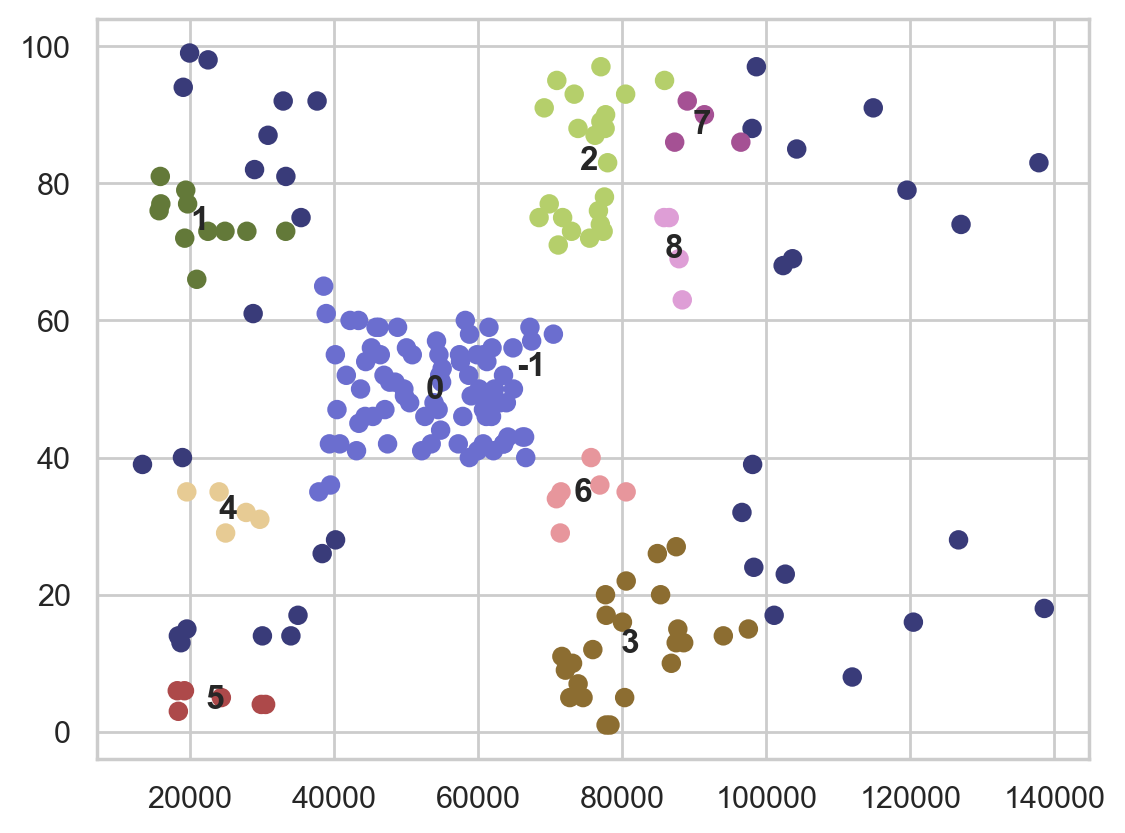

In [26]:
plt.scatter(money_situation_db['Ingreso'], money_situation_db['Puntaje_Gasto'], c=clusters_dbscan, cmap='tab20b')

for cluster_id in np.unique(clusters_dbscan):
    subset = money_situation_db[clusters_dbscan == cluster_id]
    cx = subset['Ingreso'].mean()
    cy = subset['Puntaje_Gasto'].mean()
    plt.text(cx, cy, str(cluster_id), fontsize=12, fontweight='bold', ha='center', va='center')

plt.show()

In [27]:
print(money_situation_db.groupby("cluster_dbscan").describe())

               Ingreso                                                    \
                 count          mean           std       min         25%   
cluster_dbscan                                                             
-1                38.0  67304.277368  43607.136185  13458.02  29280.5500   
 0                81.0  54096.253704   8722.131913  37926.15  46455.3400   
 1                11.0  21445.835455   5482.377203  15766.84  17662.6700   
 2                22.0  75269.342273   4094.299512  68486.79  72061.3775   
 3                23.0  81158.936957   7234.441335  71651.08  75263.7900   
 4                 5.0  25252.288000   3877.353782  19604.83  24086.9500   
 5                 6.0  23481.345000   5702.031915  18284.38  18646.4925   
 6                 6.0  74504.705000   3883.447016  70888.72  71451.9875   
 7                 4.0  91062.852500   3986.774182  87301.41  88609.1925   
 8                 4.0  87153.952500   1181.755023  85808.16  86361.5475   

           

**Estrategia de marketing despuésde DBSCAN**

* *Caso 1* Se quiere alcanzar a la mayor cantidad de personas, la estrategía debería enfocarse en el grupo 0. Este es el grupo más grande y homogéneo. Con respecto a las resultados encontramos cuando utilizamos clúster jerárquico, encontramos un grupo mayoritario más homgenéo y numeroso. Lo que hace ha este grupo aún más atractivo si el objetivo de la campaña es llegar al mayor número de personas. 
* *Caso 2* Se quiere vender un producto de lujo, la estrategía debería enfocarse en el grupo 3. Este grupo tiene el mayor nivel de ingreso y el menor puntaje de gastos, por lo tanto tienen un mayor ingreso disponible. Con respecto a los grupos que encontramos cuando utilizamos clúster jerárquico. Este grupo es más homogeneó entre sí, lo que implica que la campaña podría ser más efectiva por el mayor parecido de los inviduos. Al usar DBSCAN encontramos que tuvimos uns segmentación de los personas con mayores ingreso, el grupo 2 tienen altos ingreso y altos niveles de gasto. Por lo que podrían no tener ingreso disponible para comprar bienes de lujo o tal vez prefieran hacerlo por medio de alguna forma de financiación. 

>Nota: La base cuenta con una cantidad considerable de personas (38) con perfiles particulares, que en promedio no encajan en níngun grupo. DBSCAN nos ayudo a indentificarlas y a ver que no vale pena hacer enfocar la campaña de marketing en individuos tan particuales cuando se puede dirigir los esfuerzos a los grupos más grandes. Además, los grupos 4-8 cuentan con pocos miembros. Lo que los muestra como poco atractivos para enfocar esfuerzos en ellos cuando hay alnernativas más homogéneas y grandes. 

### 5. Incorporando más dimensiones

Hasta este momento hemos utilizado solo dos variables para nuestro análisis, sin embargo, la base cuenta con otras variables más: género y edad. Usando las categorías de edad creadas anteriormente incorpore género y grupo etario a su análisis. Genere los grupos utilizando DBSCAN y la distancia de Gower, justificando su elección de `min_samples` y `eps`   ¿Incorporar estas variables, ayuda a la focalización de la estrategia de marketing?

#### 5.1 Preparar los datos para el análisis

Para preparar los datos vamos a: 
* Volver las variables categóricas binarias
* Estandarizar las variables númericas. Esto lo haremos más adelante usando la función scale()

In [28]:
#Volver binaria la variable de rango etario
clientes_db = pd.get_dummies(clientes_db, columns=["Rango_Etario"], drop_first = True)

#Volver binaria la variable de género 
clientes_db.loc[:, "Genero"] = clientes_db["Genero"].replace({"Hombre": 0, "Mujer": 1})

#Ver la base con las variables categóricas 
clientes_db.head()


/var/folders/nb/vtcsx_lj1yq4skfdq47wggjw0000gn/T/ipykernel_61191/1139014935.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  clientes_db.loc[:, "Genero"] = clientes_db["Genero"].replace({"Hombre": 0, "Mujer": 1})
/var/folders/nb/vtcsx_lj1yq4skfdq47wggjw0000gn/T/ipykernel_61191/1139014935.py:5: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  clientes_db.loc[:, "Genero"] = clientes_db["Genero"].replace({"Hombre": 0, "Mujer": 1})
/var/folders/nb/vtcsx_lj1yq4skfdq47wggjw0000gn/T/ipykernel_61191/1139014935.py:5: FutureWarning: Setting an item of incom

,Genero,Edad,Ingreso,Puntaje_Gasto,Rango_Etario_25-34,Rango_Etario_35-44,Rango_Etario_45-54,Rango_Etario_55-64,Rango_Etario_65+
Id_Cliente,,,,,,,,,
1,1,41,98115.05,39,False,True,False,False,False
2,1,20,35458.14,75,False,False,False,False,False
3,1,68,59872.08,55,False,False,False,False,True
4,0,63,48508.93,51,False,False,False,True,False
5,1,31,44431.11,54,True,False,False,False,False


In [29]:
#Conservar solo las variables que nos interesan para el análisis 
cols_to_keep = [
    'Genero', 'Ingreso', 'Puntaje_Gasto', 
    'Rango_Etario_25-34', 'Rango_Etario_35-44', 
    'Rango_Etario_45-54', 'Rango_Etario_55-64', 'Rango_Etario_65+'
]

clientes_sub_db = clientes_db[cols_to_keep].copy()

#### 5.2 Definir hiparámetros

In [30]:
#Calcular las distancias usando Gower -------------------------
import gower
dist_matrix = gower.gower_matrix(clientes_sub_db.astype(float))

In [ ]:
#Calcular el radio el radio de búsqueda(eps) --------------------------

from sklearn.neighbors import NearestNeighbors
from kneed import KneeLocator
import numpy as np

k = 4
nbrs = NearestNeighbors(n_neighbors=k, metric='precomputed')
nbrs.fit(dist_matrix)
distances, indices = nbrs.kneighbors(dist_matrix)

distancias = np.sort(distances[:, -1])

i = np.arange(len(distancias))
knee = KneeLocator(i, distancias, S=1, curve='convex', direction='increasing', interp_method='polynomial')

print(f"eps: {distancias[knee.knee]}")

Optimal eps: 0.037312548607587814


> EPS: 0.04

Vamos a usar 4 vecinos a partir al igual que en el caso anterior 
#### 5.3 Ejecutar DBSCAN con más dimensiones

In [ ]:
db = DBSCAN(eps=0.04, min_samples=4, metric='precomputed') #Especificamos que le estamos pasanod una matriz de distancias, si no lo hacemos, calcula la distancia euclidiana por default
clusters_dbscan_2 = db.fit_predict(dist_matrix)

In [41]:
#Agregar el clúster en el que quedo asignada cada persona 
clientes_sub_db.loc[:, "cluster_dbscan"] = clusters_dbscan_2

#Vemos cuantas personas hay por clúster
print("Número de personas por clúster")
print(clientes_sub_db["cluster_dbscan"].value_counts())

Número de personas por clúster
cluster_dbscan
 4     32
 0     22
-1     22
 10    20
 1     18
 5     17
 8     14
 6     12
 9     10
 7      8
 12     6
 2      5
 11     5
 13     5
 3      4
Name: count, dtype: int64


# Referencias

- Ester, M., H. P. Kriegel, J. Sander, and X. Xu. (1996). A Density-Based Algorithm for Discovering Clusters in Large Spatial Databases with Noise. In Proceedings of the 2nd International Conference on Knowledge Discovery and Data Mining, Portland, OR, AAAI Press, pp. 226–231.

- Sander, J., Ester, M., Kriegel, HP. et al. Density-Based Clustering in Spatial Databases: The Algorithm GDBSCAN and Its Applications. Data Mining and Knowledge Discovery 2, 169–194 (1998). https://doi.org/10.1023/A:1009745219419